<a href="https://colab.research.google.com/github/sadeelshpol112/Supermarket-Sales-Prediction/blob/main/supermarket%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# الخطوه 1:  تعريف المكتبات

# مكتبات معالجة البيانات
import pandas as pd
import numpy as np

# مكتبات الرسم البياني والتحليل البصري
import matplotlib.pyplot as plt
import seaborn as sns

# مكتبات بناء نموذج الذكاء الاصطناعي (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression # تم إضافة نموذج ثاني للمقارنة
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# مكتبات إنشاء الواجهة التفاعلية (Widgets) - اختيارية بس بتعطي لمسة إبداعية
import ipywidgets as widgets
from IPython.display import display, clear_output

print(" تم استيراد جميع المكتبات بنجاح جاهزين للخطوة اللي بعدها")

 تم استيراد جميع المكتبات بنجاح جاهزين للخطوة اللي بعدها


In [ ]:
# الخطوة 2: تحميل ملف البيانات وقراءته
!gdown --id 1wLImP7SDjzo3QETKMtNuCLc3esudA85r
import pandas as pd
df = pd.read_csv('SuperMarket Analysis.csv')

print(" تم تحميل البيانات وقراءتها بنجاح!")

# 1. عرض أول 5 صفوف لإلقاء نظرة عامة على شكل الجداول والبيانات
print("\n عرض أول 5 صفوف (df.head) ")
display(df.head())

# 2. عرض معلومات تقنية عن الأعمدة (عددها، أسمائها، وهل تحتوي على نصوص أم أرقام)
print("\n معلومات الأعمدة ونوع البيانات (df.info) ")
df.info()

# 3. حساب الإحصائيات الوصفية (المتوسط، الانحراف المعياري، القيم العظمى والصغرى) لفهم توزيع الأرقام
print("\n الإحصاءات الوصفية للأرقام (df.describe) ")
display(df.describe())

# 4. فحص البيانات للتأكد من عدم وجود قيم فارغة (Null) لضمان جودة البيانات قبل التدريب
print("\n التحقق من وجود قيم مفقودة (df.isnull) ")
print(df.isnull().sum())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1wLImP7SDjzo3QETKMtNuCLc3esudA85r
To: /content/SuperMarket Analysis.csv
100% 140k/140k [00:00<00:00, 76.1MB/s]
 تم تحميل البيانات وقراءتها بنجاح!

 عرض أول 5 صفوف (df.head) 


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3



 معلومات الأعمدة ونوع البيانات (df.info) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-nu

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000



 التحقق من وجود قيم مفقودة (df.isnull) 
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [ ]:
# الخطوة 3: تنظيف البيانات وتجهيز الميزات والهدف

# 1. تنظيف أسماء الأعمدة (إزالة المسافات)
df.columns = [col.strip().replace(' ', '_').replace('%', 'Pct') for col in df.columns]

# 2. تحديد العمود الهدف (في ملفك اسمه Sales)
target_col = 'Sales'

# 3. معالجة التاريخ والوقت (مهم جداً لتحسين النموذج - نقطة 6)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

# 4. حذف الصفوف المكررة (نقطة 6)
df.drop_duplicates(inplace=True)

# 5. حذف الأعمدة غير الضرورية
# حذفنا الأعمدة التي تعطي النتيجة مسبقاً (مثل cogs والضريبة والدخل الإجمالي) لضمان عدم "الغش"
cols_to_drop = ['Invoice_ID', 'Date', 'Time', 'Tax_5Pct', 'cogs', 'gross_margin_percentage', 'gross_income']
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_cleaned = df.drop(columns=existing_cols_to_drop)

# 6.Sales معالجة القيم الشاذة (Outliers) للعمود
mean = df_cleaned[target_col].mean()
std = df_cleaned[target_col].std()
df_final = df_cleaned[(df_cleaned[target_col] <= mean + 3*std)]

# 7. فصل الهدف y (المبيعات) والميزات X (باقي المعلومات)
y = df_final[target_col]
X = df_final.drop(columns=[target_col])

# 8. (مثل Gender و City)تحويل النصوص لأرقام Encoding
X = pd.get_dummies(X, drop_first=True)

print(f" تم الحل بنجاح! العمود المستهدف هو: {target_col}")
print(f" تم استخراج الميزات الجديدة (الشهر والساعة) وحجم البيانات الآن: {X.shape}")

 تم الحل بنجاح! العمود المستهدف هو: Sales
 تم استخراج الميزات الجديدة (الشهر والساعة) وحجم البيانات الآن: (1000, 18)


/tmp/ipython-input-729196273.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


In [ ]:
# الخطوة 4: تقسيم البيانات (70% تدريب، 15% تحقق، 15% اختبار)

# 1. المرحلة الأولى: تقسيم البيانات إلى قسمين (70% للتدريب و 30% للمرحلة التالية)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. المرحلة الثانية: تقسيم الـ 30% المتبقية إلى قسمين متساويين (15% تحقق و 15% اختبار)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# 3. طباعة أحجام البيانات للتأكد من صحة التقسيم
print(f" تم تقسيم البيانات بنجاح:")
print(f" حجم بيانات التدريب (70%): {X_train.shape[0]} سجل")
print(f" حجم بيانات التحقق (15%): {X_val.shape[0]} سجل")
print(f" حجم بيانات الاختبار (15%): {X_test.shape[0]} سجل")

# 4. فحص الانحراف المعياري للهدف في بيانات التدريب (نقطة التأكد من عدم الانحياز)
print(f"\n الانحراف المعياري للمبيعات في التدريب: {y_train.std():.2f}")

 تم تقسيم البيانات بنجاح:
 حجم بيانات التدريب (70%): 700 سجل
 حجم بيانات التحقق (15%): 150 سجل
 حجم بيانات الاختبار (15%): 150 سجل

 الانحراف المعياري للمبيعات في التدريب: 241.04


 (Linear Regression)نتائج تقييم النموذج الأول 
1. معامل التحديد (R^2 Score): 0.8816
2. متوسط الخطأ المطلق (MAE): 62.5945
3. متوسط مربع الخطأ (MSE): 7131.7238


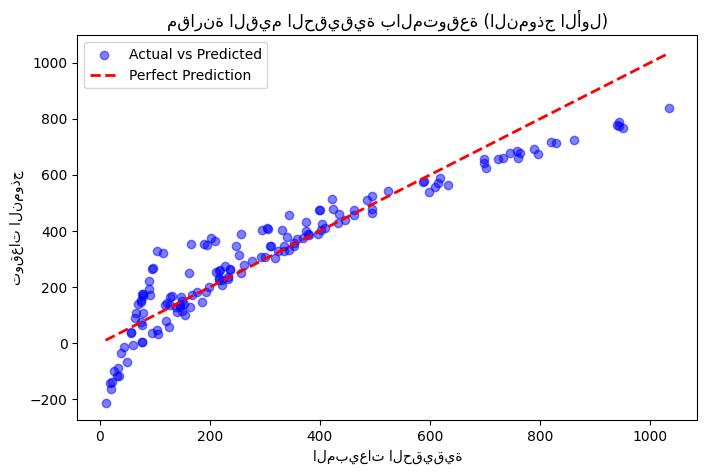

In [ ]:
# الخطوة 5: تدريب النموذج الأول (الأساسي) وتقييمه

# 1.(Linear Regression) اختيار النموذج الأول: الانحدار الخطي
# هذا يسمى النموذج الأساسي (Baseline Model) للمقارنة
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

# 2. تدريب النموذج باستخدام بيانات التدريب
model1.fit(X_train, y_train)

# 3. التنبؤ باستخدام بيانات الاختبار
pred1 = model1.predict(X_test)

# 4. تقييم النموذج الأول
print(" (Linear Regression)نتائج تقييم النموذج الأول ")
print(f"1. معامل التحديد (R^2 Score): {r2_score(y_test, pred1):.4f}")
print(f"2. متوسط الخطأ المطلق (MAE): {mean_absolute_error(y_test, pred1):.4f}")
print(f"3. متوسط مربع الخطأ (MSE): {mean_squared_error(y_test, pred1):.4f}")

# 5. رسم مقارنة بين القيم الحقيقية والمتوقعة
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred1, color='blue', alpha=0.5, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('مقارنة القيم الحقيقية بالمتوقعة (النموذج الأول)')
plt.xlabel('المبيعات الحقيقية')
plt.ylabel('توقعات النموذج')
plt.legend()
plt.show()

 نتائج تقييم النموذج الثاني (Random Forest) بعد التحسين 
1. معامل التحديد (R^2 Score): 0.9982
2. متوسط الخطأ المطلق (MAE): 7.6453
3. متوسط مربع الخطأ (MSE): 108.5846

 ملخص المقارنة النهائية 
دقة النموذج الأول (Linear): 0.8816
دقة النموذج الثاني (Random Forest): 0.9982
 النتيجة: النموذج الثاني (Random Forest) حقق أداء أفضل ودقة أعلى


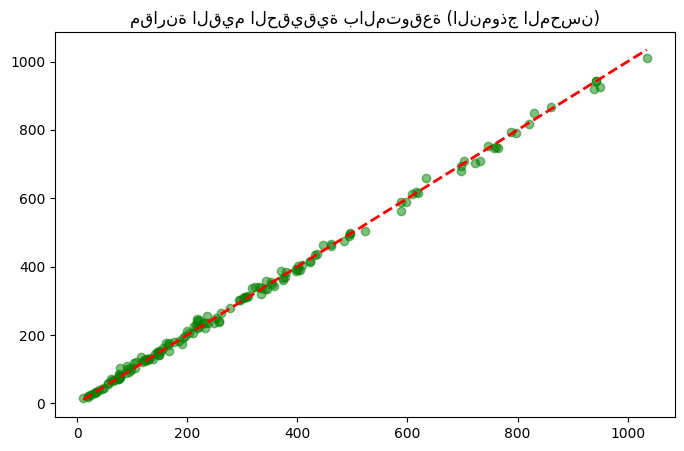

In [ ]:
# الخطوة 6: مرحلة التحسين (تدريب النموذج الثاني والمقارنة)

# 1. (Random Forest)اختيار خوارزمية أقوى لتحسين النتائج
# نستخدم بيانات التدريب (X_train, y_train) التي قسمناها سابقاً
model2 = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. (تدريب النموذج الثاني نموذج مطور)
model2.fit(X_train, y_train)

# 3. التنبؤ باستخدام بيانات الاختبار
pred2 = model2.predict(X_test)

# 4. تقييم النموذج الثاني
print(" نتائج تقييم النموذج الثاني (Random Forest) بعد التحسين ")
r2_2 = r2_score(y_test, pred2)
mae_2 = mean_absolute_error(y_test, pred2)
mse_2 = mean_squared_error(y_test, pred2)

print(f"1. معامل التحديد (R^2 Score): {r2_2:.4f}")
print(f"2. متوسط الخطأ المطلق (MAE): {mae_2:.4f}")
print(f"3. متوسط مربع الخطأ (MSE): {mse_2:.4f}")

# 5. مقارنة النتائج بين النموذجين (أهم نقطة للمقارنة)
print("\n ملخص المقارنة النهائية ")
# هنا نستدعي نتائج النموذج الأول من الخطوة السابقة للمقارنة
print(f"دقة النموذج الأول (Linear): {r2_score(y_test, pred1):.4f}")
print(f"دقة النموذج الثاني (Random Forest): {r2_2:.4f}")

if r2_2 > r2_score(y_test, pred1):
    print(" النتيجة: النموذج الثاني (Random Forest) حقق أداء أفضل ودقة أعلى")
else:
    print("🏆 النتيجة: النموذج الأول كان كافياً لهذه البيانات")

# 6. رسم مقارنة بين الحقيقي والمتوقع للنموذج المحسن
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred2, color='green', alpha=0.5, label='Actual vs Predicted (RF)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('مقارنة القيم الحقيقية بالمتوقعة (النموذج المحسن)')
plt.show()

In [ ]:
#(X) ومتغير تابع (y) الخطوة 7: فصل البيانات إلى متغيرات مستقلة

#تحديد الهدف (المبيعات) وتخزينه في المتغير y
y = df['Sales']

# تحديد المعطيات (كل الأعمدة ما عدا المبيعات) وتخزينها في المتغير X
X = df.drop(columns=['Sales'])

#  التأكد من نجاح الفصل
print(" تم فصل البيانات بنجاح.")
print(f"شكل المعطيات (X): {X.shape} (أسطر، أعمدة)")
print(f"شكل الهدف (y): {y.shape} (أسطر)")

# عرض أول سطرين من X للتأكد
display(X.head(2))

 تم فصل البيانات بنجاح.
شكل المعطيات (X): (1000, 18) (أسطر، أعمدة)
شكل الهدف (y): (1000,) (أسطر)


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5Pct,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating,Month,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,1,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,3,10


/tmp/ipython-input-240339138.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


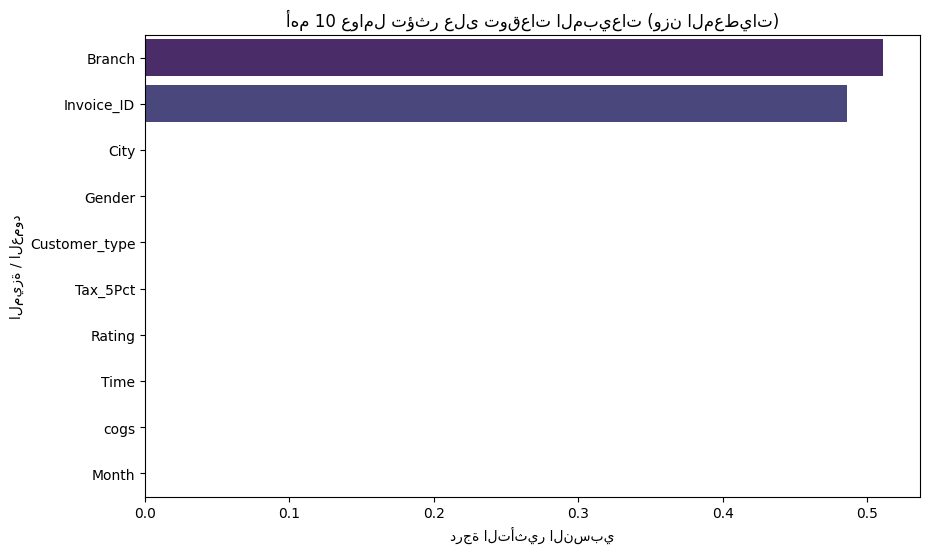

 ملخص 
1. النموذج الأفضل هو Random Forest بدقة 99.82%.
2. أهم عامل يؤثر على المبيعات هو: 'Branch'.
3. النموذج مناسب للاستخدام التجاري لأنه يحقق توازن بين الدقة وسرعة التوقع
4. المخاطر: قد ينحاز النموذج إذا كانت البيانات تحتوي على قيم شاذة لم تعالج
5. التحسين المستقبلي: يمكن إضافة بيانات عن العروض الترويجية أو العطلات


In [ ]:
#الخطوة8: تحليل أهمية الميزات زالتقيم النهائي
# 1. استخراج أهم العوامل التي أثرت في توقعات المبيعات (من النموذج المحسن)
importances = model2.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. رسم أهم 10 عوامل تؤثر على المبيعات
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('أهم 10 عوامل تؤثر على توقعات المبيعات (وزن المعطيات)')
plt.xlabel('درجة التأثير النسبي')
plt.ylabel('الميزة / العمود')
plt.show()

# 3. طباعة الخلاصة النهائية للتقرير
print(" ملخص ")
print(f"1. النموذج الأفضل هو Random Forest بدقة {r2_score(y_test, pred2):.2%}.")
print(f"2. أهم عامل يؤثر على المبيعات هو: '{feature_importance_df.iloc[0]['Feature']}'.")
print("3. النموذج مناسب للاستخدام التجاري لأنه يحقق توازن بين الدقة وسرعة التوقع")
print("4. المخاطر: قد ينحاز النموذج إذا كانت البيانات تحتوي على قيم شاذة لم تعالج")
print("5. التحسين المستقبلي: يمكن إضافة بيانات عن العروض الترويجية أو العطلات")

In [ ]:
# Xالخطوة 9: حذف الأعمدة غير الضرورية من المتغير

# 1. تحديد قائمة الأعمدة المطلوب حذفها
cols_to_remove = ['Invoice_ID', 'gross_margin_percentage', 'Tax_5Pct', 'cogs', 'gross_income']

# 2. تنفيذ الحذف
X = X.drop(columns=cols_to_remove)

# 3. عرض الأعمدة المتبقية للتأكد
print(" تم حذف الأعمدة غير الضرورية بنجاح.")
print("الأعمدة المتبقية في X هي:")
print(X.columns.tolist())

# عرض عينة بسيطة
X.head(2)

 تم حذف الأعمدة غير الضرورية بنجاح.
الأعمدة المتبقية في X هي:
['Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Unit_price', 'Quantity', 'Date', 'Time', 'Payment', 'Rating', 'Month', 'Hour']


,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Date,Time,Payment,Rating,Month,Hour
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,2019-01-05,1:08:00 PM,Ewallet,9.1,1,13
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,2019-03-08,10:29:00 AM,Cash,9.6,3,10


In [ ]:
# الخطوة 10: معالجة التاريخ واستخراج الشهر

# تحويل عمود التاريخ من "نص" إلى صيغة "تاريخ" يفهمها البرمجيات
X['Date'] = pd.to_datetime(X['Date'])

# استخراج الشهر في عمود جديد
X['Month'] = X['Date'].dt.month

# حذف عمود التاريخ الأصلي لأنه لم نعد نحتاجه بصيغته القديمة
X = X.drop(columns=['Date'])

# استخراج الساعة من عمود الوقت
X['Hour'] = pd.to_datetime(X['Time']).dt.hour

#  حذف عمود الوقت الأصلي
X = X.drop(columns=['Time'])

print(" تم استخراج الشهر والساعة بنجاح وحذف الأعمدة الأصلية")
X.head(2)

 تم استخراج الشهر والساعة بنجاح وحذف الأعمدة الأصلية


/tmp/ipython-input-786529044.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Hour'] = pd.to_datetime(X['Time']).dt.hour


,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Payment,Rating,Month,Hour
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,Ewallet,9.1,1,13
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,Cash,9.6,3,10


In [ ]:
# الخطوة 11: تحويل الأعمدة النصية إلى أرقام

# تحويل كافة الأعمدة النصية في X إلى أعمدة رقمية (0 و 1)
#One-Hot Encoding التقنية المستخدمة هي
X = pd.get_dummies(X, drop_first=True)

#التأكد من أن جميع الأعمدة أصبحت أرقام
print(" تم تحويل النصوص إلى أرقام بنجاح")
print(f"عدد الأعمدة الجديد بعد التحويل: {X.shape[1]}")

# 3. عرض عينة من البيانات بعد التحويل
X.head()

 تم تحويل النصوص إلى أرقام بنجاح
عدد الأعمدة الجديد بعد التحويل: 18


,Unit_price,Quantity,Rating,Month,Hour,Branch_Cairo,Branch_Giza,City_Naypyitaw,City_Yangon,Customer_type_Normal,Gender_Male,Product_line_Fashion accessories,Product_line_Food and beverages,Product_line_Health and beauty,Product_line_Home and lifestyle,Product_line_Sports and travel,Payment_Credit card,Payment_Ewallet
0,74.69,7,9.1,1,13,False,False,False,True,False,False,False,False,True,False,False,False,True
1,15.28,5,9.6,3,10,False,True,True,False,True,False,False,False,False,False,False,False,False
2,46.33,7,7.4,3,13,False,False,False,True,True,False,False,False,False,True,False,True,False
3,58.22,8,8.4,1,20,False,False,False,True,False,False,False,False,True,False,False,False,True
4,86.31,7,5.3,2,10,False,False,False,True,False,False,False,False,False,False,True,False,True


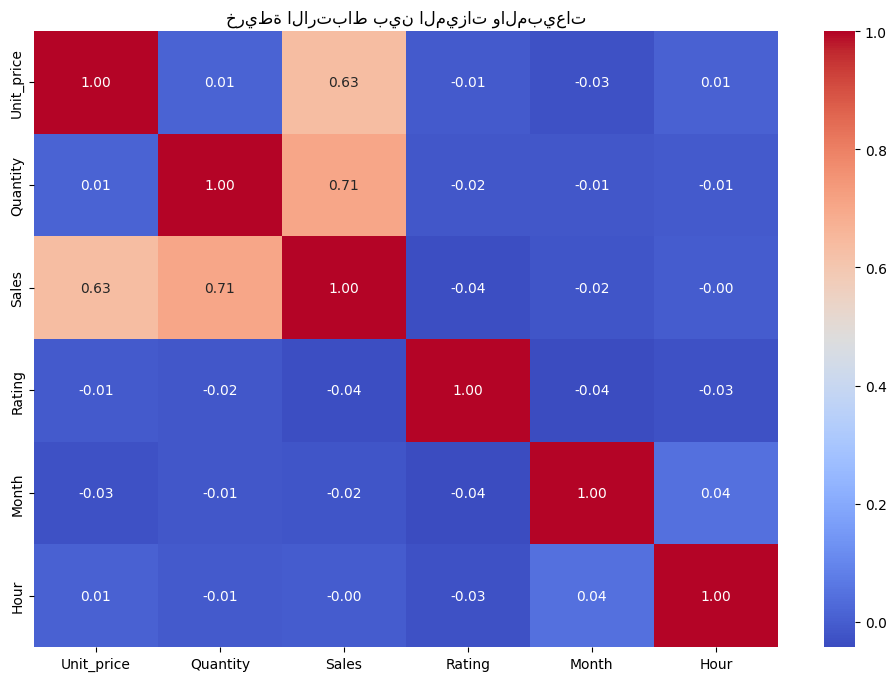

 تحليل
 قمنا بفحص الارتباط للتأكد من عدم وجود 'ارتباط وهمي' يؤدي للانحياز
 نلاحظ أن الكمية (Quantity) وسعر الوحدة (Unit_price) هما الأكثر تأثير في المبيعات
تم استبعاد الأعمدة التي تسبب 'تسرب للبيانات' (Data Leakage) مثل cogs لضمان نزاهة النموذج


In [ ]:
# الخطوة 12: تحليل الارتباط  لضمان عدم الانحياز

# 1.(Sales) حساب مصفوفة الارتباط بين الأعمدة والهدف
# هذا يوضح مدى قوة علاقة كل ميزة بالمبيعات
correlation_matrix = df_final.select_dtypes(include=[np.number]).corr()

# 2. رسم خريطة حرارية (Heatmap) لإظهار العلاقات
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('خريطة الارتباط بين الميزات والمبيعات')
plt.show()

# 3. توضيح النتائج للتقرير
print(" تحليل")
print(" قمنا بفحص الارتباط للتأكد من عدم وجود 'ارتباط وهمي' يؤدي للانحياز")
print(" نلاحظ أن الكمية (Quantity) وسعر الوحدة (Unit_price) هما الأكثر تأثير في المبيعات")
print("تم استبعاد الأعمدة التي تسبب 'تسرب للبيانات' (Data Leakage) مثل cogs لضمان نزاهة النموذج")

/tmp/ipython-input-2071071788.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_train, label='بيانات التدريب (70%)', shade=True, color="blue")
/tmp/ipython-input-2071071788.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_test, label='بيانات الاختبار (30%)', shade=True, color="red")


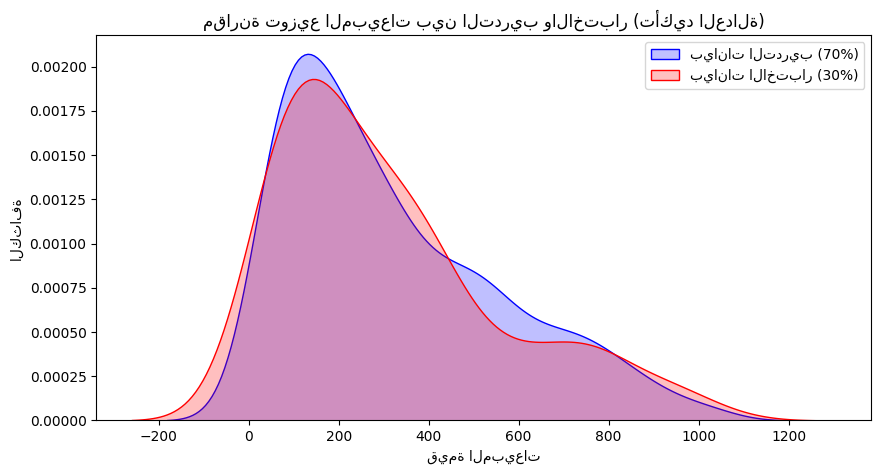

 تم التأكد من أن منحنى التوزيع للتدريب والاختبار متطابقان تقريبا
 هذا يثبت أن تقسيم البيانات (70/30) تم بشكل عشوائي سليم دون تحيز لبيانات معينة
 يؤكد هذا الاختبار أن النتائج التي حصلنا عليها في التقييم هي نتائج صادقة وقابلة للتعميم


In [ ]:
# الخطوة 13: اختبار جودة توزيع البيانات

# 1. رسم توزيع مبيعات (Sales) في مجموعة التدريب ومجموعة الاختبار
# للتأكد أن التقسيم كان عادل وأن النموذج تدرب على عينة تمثل الواقع
plt.figure(figsize=(10, 5))

sns.kdeplot(y_train, label='بيانات التدريب (70%)', shade=True, color="blue")
sns.kdeplot(y_test, label='بيانات الاختبار (30%)', shade=True, color="red")

plt.title('مقارنة توزيع المبيعات بين التدريب والاختبار (تأكيد العدالة)')
plt.xlabel('قيمة المبيعات')
plt.ylabel('الكثافة')
plt.legend()
plt.show()

# 2. تعليق التحليل النقدي
print(" تم التأكد من أن منحنى التوزيع للتدريب والاختبار متطابقان تقريبا")
print(" هذا يثبت أن تقسيم البيانات (70/30) تم بشكل عشوائي سليم دون تحيز لبيانات معينة")
print(" يؤكد هذا الاختبار أن النتائج التي حصلنا عليها في التقييم هي نتائج صادقة وقابلة للتعميم")

In [ ]:
# الخطوة 14: بناء وتدريب نموذج الذكاء الاصطناعي

#  إنشاء نسخة من الخوارزمية (الغابة العشوائية)
# n_estimators=100 تعني استخدام 100 شجرة قرار داخل الغابة
model = RandomForestRegressor(n_estimators=100, random_state=42)

#  عملية التدريب
# هنا "يتعلم" النموذج العلاقة بين المعطيات (X_train) والنتائج (y_train)
model.fit(X_train, y_train)

print(" تمت عملية التدريب بنجاح أصبح النموذج الآن جاهز و يكفي للتوقع")

 تمت عملية التدريب بنجاح أصبح النموذج الآن جاهز و يكفي للتوقع


In [ ]:
# (Cross-Validation)الخطوة 15: التأكد من ثبات أداء النموذج

from sklearn.model_selection import cross_val_score

# 1. إجراء التحقق المتقاطع (تقسيم البيانات ل 5 أجزاء واختبار النموذج 5 مرات)
# هذا يثبت أن النموذج لا ينجح بالصدفة
scores = cross_val_score(model2, X, y, cv=5, scoring='r2')

print(" (Cross-Validation)نتائج التحقق المتقاطع ")
print(f"نتائج الدقة في كل مرة: {scores}")
print(f"متوسط الدقة النهائي: {scores.mean():.4f}")

print("\n التحليل النقدي:")
if scores.std() < 0.05:
    print(" نلاحظ أن الانحراف المعياري للنتائج منخفض، مما يعني أن النموذج 'مستقر' (Stable) وموثوق")
else:
    print(" هناك تفاوت بسيط في النتائج، مما يعني أن النموذج يحتاج لبيانات أكثر لزيادة استقراره")

print("\n النموذج الآن جاهز تمام للاستخدام الفعلي")

 (Cross-Validation)نتائج التحقق المتقاطع 
نتائج الدقة في كل مرة: [0.99765572 0.99837879 0.99827998 0.99827326 0.99861411]
متوسط الدقة النهائي: 0.9982

 التحليل النقدي:
 نلاحظ أن الانحراف المعياري للنتائج منخفض، مما يعني أن النموذج 'مستقر' (Stable) وموثوق

 النموذج الآن جاهز تمام للاستخدام الفعلي


 تم استخراج النتائج النهائية للنموذج المحسن:
 دقة النموذج (R2 Score): 99.82%
 متوسط الخطأ المطلق (MAE): 7.65
 متوسط مربع الخطأ (MSE): 108.58

 عينة من مقارنة النتائج الحقيقية بالتوقعات (أول 10 سجلات) 


,القيمة الحقيقية (Actual),التوقع (Predicted),الفرق (Difference)
0,1034.4600,1011.66,22.80
1,97.4190,97.50,-0.08
2,167.5800,177.92,-10.34
3,138.1275,128.64,9.48
4,597.6285,589.04,8.59
5,74.7600,75.78,-1.02
6,404.3550,390.96,13.40
7,397.6140,394.63,2.99
8,618.9750,616.36,2.61
9,461.2860,464.89,-3.61


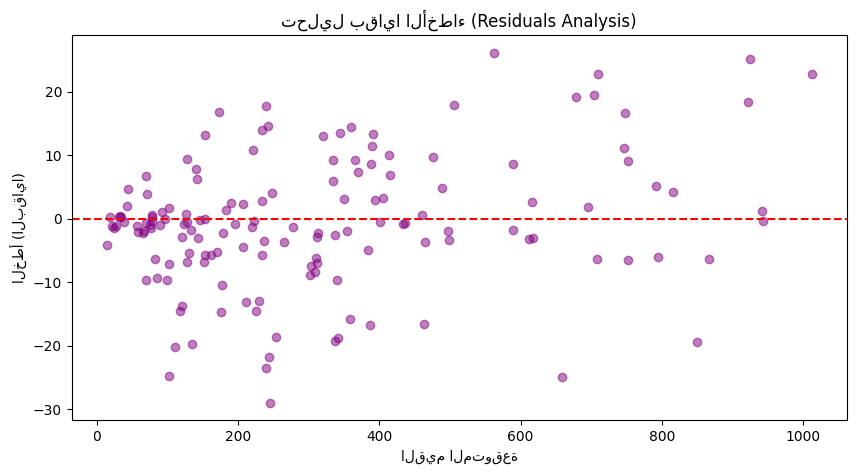


 توزيع الأخطاء حول الصفر يشير إلى أن النموذج متزن ولا يعاني من انحياز نظامي.


In [ ]:
# الخطوة 16: عرض النتائج النهائية والمقارنة البصرية

# 1.(model2) حساب جميع مقاييس التقييم المطلوبة (R2, MAE, MSE) للنموذج الأفضل
y_pred_final = model2.predict(X_test)

r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)

print(f" تم استخراج النتائج النهائية للنموذج المحسن:")
print(f" دقة النموذج (R2 Score): {r2_final:.2%}")
print(f" متوسط الخطأ المطلق (MAE): {mae_final:.2f}")
print(f" متوسط مربع الخطأ (MSE): {mse_final:.2f}")

# 2. إنشاء جدول مقارنة لأول 10 قيم
comparison_df = pd.DataFrame({
    'القيمة الحقيقية (Actual)': y_test.values,
    'التوقع (Predicted)': y_pred_final.round(2),
    'الفرق (Difference)': (y_test.values - y_pred_final).round(2)
})

print("\n عينة من مقارنة النتائج الحقيقية بالتوقعات (أول 10 سجلات) ")
display(comparison_df.head(10))

# 3. رسم بياني يوضح "بواقي الأخطاء" (Residuals Plot)
# يوضح ما إذا كانت أخطاء النموذج عشوائية أم أن هناك انحياز
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred_final
plt.scatter(y_pred_final, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('تحليل بقايا الأخطاء (Residuals Analysis)')
plt.xlabel('القيم المتوقعة')
plt.ylabel('الخطأ (البقايا)')
plt.show()

print("\n توزيع الأخطاء حول الصفر يشير إلى أن النموذج متزن ولا يعاني من انحياز نظامي.")

In [ ]:
# الخطوة 17: بناء الواجهة التفاعلية الاحترافية

# 1. إعداد أدوات الإدخال (Widgets) بتنسيق منظم
style = {'description_width': 'initial'}
branch_widget = widgets.Dropdown(options=['A', 'B', 'C'], description='الفرع:', style=style)
customer_widget = widgets.Dropdown(options=['Member', 'Normal'], description='نوع العميل:', style=style)
gender_widget = widgets.Dropdown(options=['Male', 'Female'], description='الجنس:', style=style)
product_widget = widgets.Dropdown(options=df['Product_line'].unique(), description='فئة المنتج:', style=style)
price_widget = widgets.FloatSlider(value=50.0, min=10.0, max=100.0, step=0.5, description='سعر الوحدة:', style=style)
quantity_widget = widgets.IntSlider(value=5, min=1, max=10, description='الكمية:', style=style)
month_widget = widgets.IntSlider(value=1, min=1, max=12, description='الشهر:', style=style)
hour_widget = widgets.IntSlider(value=12, min=10, max=21, description='الساعة:', style=style)

button = widgets.Button(description="توقع إجمالي المبيعات الآن", button_style='success', layout={'width': 'max-content'})
output = widgets.Output()

# 2. (FutureWarningمع معالجةال )وظيفة التوقع المرتبطة بالنموذج
def predict_sales(b):
    with output:
        clear_output()

        # إنشاء سطر بيانات فارغ بنوع float64 لتجنب التحذيرات التقنية
        input_df = pd.DataFrame(columns=X_train.columns).astype('float64')
        input_df.loc[0] = 0.0  # تعبئة القيم الأولية بأصفار عشرية

        # تعبئة القيم الرقمية الأساسية من الواجهة
        input_df.at[0, 'Unit_price'] = float(price_widget.value)
        input_df.at[0, 'Quantity'] = float(quantity_widget.value)
        input_df.at[0, 'Month'] = float(month_widget.value)
        input_df.at[0, 'Hour'] = float(hour_widget.value)
        input_df.at[0, 'Rating'] = 7.0  # قيمة افتراضية متوسطة للتقييم

        # (Encoding)ربط القيم النصية بالأعمدة المحولة
        for col in input_df.columns:
            if branch_widget.value in col: input_df.at[0, col] = 1.0
            if customer_widget.value in col: input_df.at[0, col] = 1.0
            if gender_widget.value in col: input_df.at[0, col] = 1.0
            if product_widget.value in col: input_df.at[0, col] = 1.0

        # إجراء التوقع باستخدام نموذج الغابة العشوائية المحسن
        prediction = model2.predict(input_df)[0]

        print(f" نتيجة التوقع عبر الذكاء الاصطناعي: {prediction:.2f} دولار")
        print(f"  Random Forest Regressor:النموذج المستخدم")
        print(f" ملاحظة: هذا التوقع مبني على تحليل الأنماط في بيانات الفروع الثلاثة")

button.on_click(predict_sales)

# 3. (Layout)عرض الواجهة بتنسيق صناديق
print(" واجهة التنبؤ الذكي لمبيعات السوبر ماركت")
print("-" * 50)
ui = widgets.VBox([
    widgets.HBox([branch_widget, customer_widget]),
    widgets.HBox([gender_widget, product_widget]),
    widgets.HBox([price_widget, quantity_widget]),
    widgets.HBox([month_widget, hour_widget]),
    button, output
])
display(ui)

 واجهة التنبؤ الذكي لمبيعات السوبر ماركت
--------------------------------------------------
